In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from src.simulators import *
from src.estimators import *

sns.set_style("darkgrid")
plt.rcParams.update({'font.size': 12, 'figure.figsize': (10, 6)})

# Stable Distribution Simulation and Parameter Estimation

This notebook validates custom implementations of:
- $\alpha$-stable simulation (CMS method)
- Parameter estimation methods:
  - McCulloch (quantile-based)
  - Koutrouvelis (ECF regression)

We test against:
- Synthetic data
- scipy reference implementations
- Theoretical properties (PDF, tails, scaling)

## $\alpha$-stable distributions

Key parameters:
- $\alpha \in $ (0,2]: stability (tail thickness)
- $\beta \in $ [-1,1]: skewness
- $\sigma>0 $\: scale
- $\mu$: location

Special cases:
- $\alpha$ = 2 - Gaussian
- $\alpha$ = 1 - Cauchy
- $\alpha$ = 0.5 - Lévy

Heavy-tail property:
$\mathbb{P}(|X| > x) \sim x^{-\alpha}$

## Testing simulation correctness


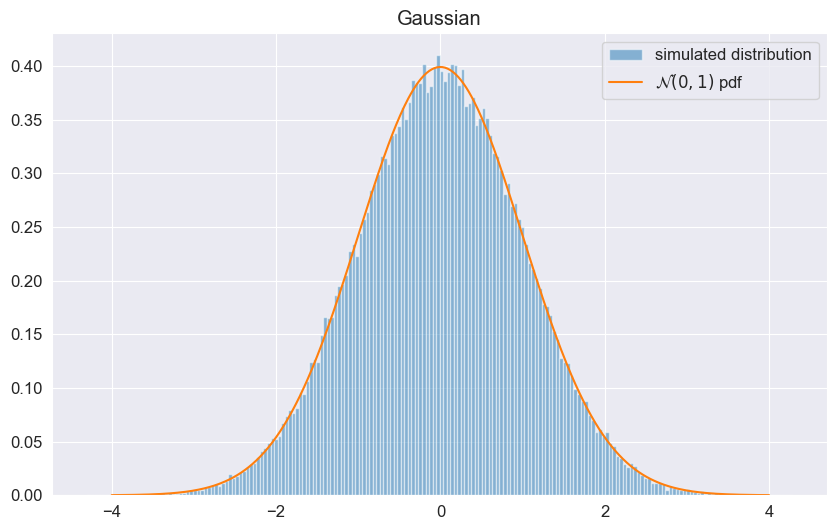

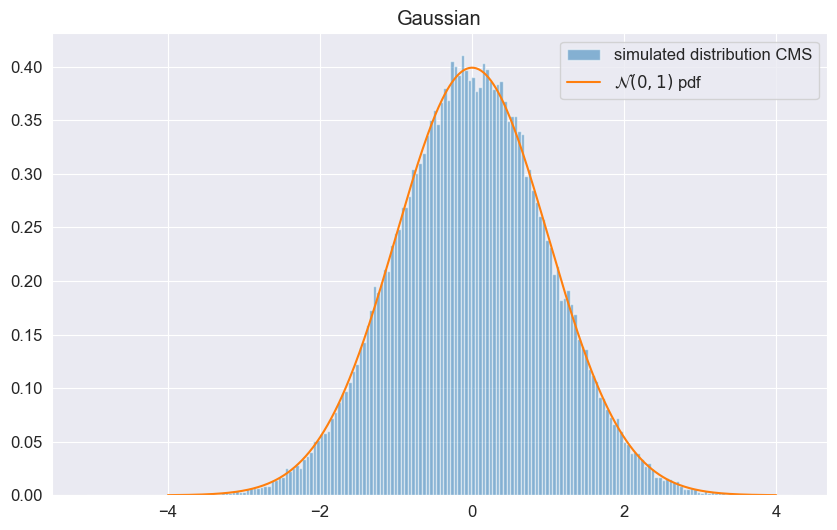

In [2]:
data = simulate_gaussian(0,1,100000)
data_cms= simulate_stable(alpha=2, beta=0,sigma=np.sqrt(0.5), n_steps=100000)

x = np.linspace(-4,4,500)
plt.hist(data, bins=200, density=True, alpha=0.5, label='simulated distribution')
plt.plot(x, stats.norm.pdf(x), label = r"$\mathcal{N}(0,1)$ pdf")
plt.title("Gaussian")
plt.legend()
plt.show()

plt.hist(data_cms, bins=200, density=True, alpha=0.5, label='simulated distribution CMS')
plt.plot(x, stats.norm.pdf(x), label = r"$\mathcal{N}(0,1)$ pdf")
plt.title("Gaussian")
plt.legend()
plt.show()

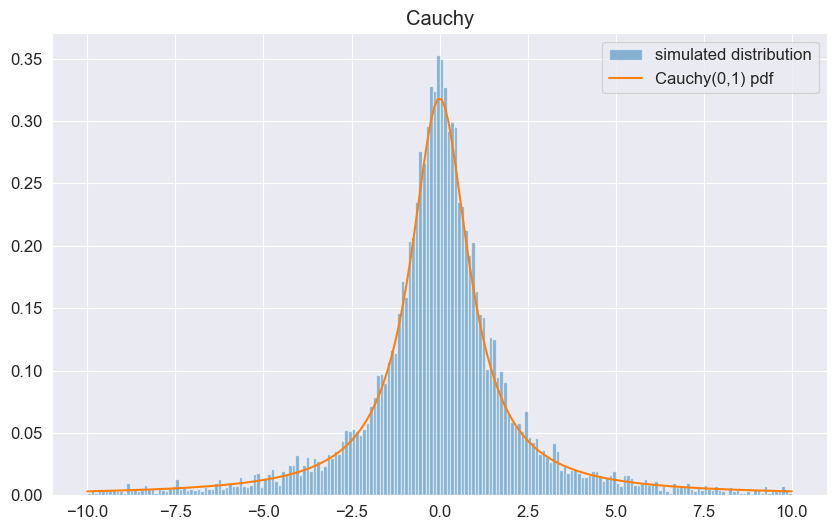

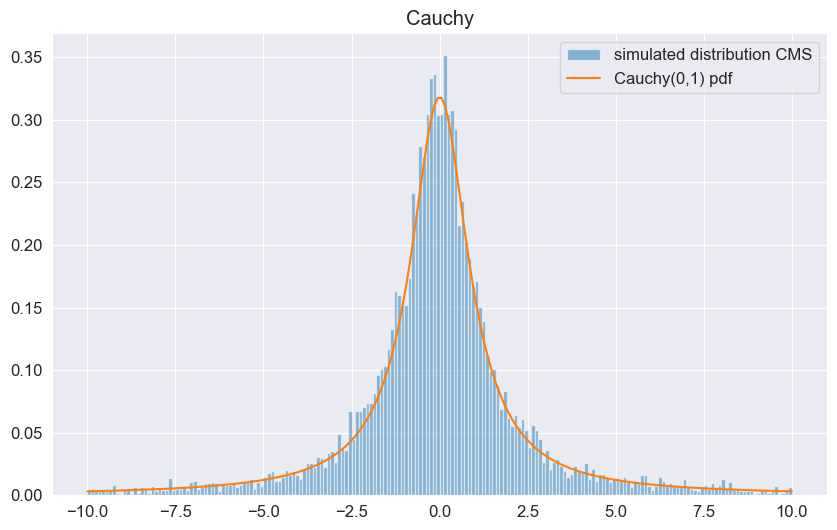

In [3]:
data = simulate_cauchy( n_steps=10000)
data_cms = simulate_stable(alpha = 1.0, beta=0.0, n_steps=10000)
x = np.linspace(-10,10,200)
plt.hist(data, bins=200, density=True, alpha=0.5, label = "simulated distribution", range=(-10, 10))
plt.plot(x, stats.cauchy.pdf(x), label = r"Cauchy(0,1) pdf")
plt.title("Cauchy")
plt.legend()
plt.show()

plt.hist(data_cms, bins=200, density=True, alpha=0.5, label = "simulated distribution CMS", range=(-10, 10))
plt.plot(x, stats.cauchy.pdf(x), label = r"Cauchy(0,1) pdf")
plt.title("Cauchy")
plt.legend()
plt.show()

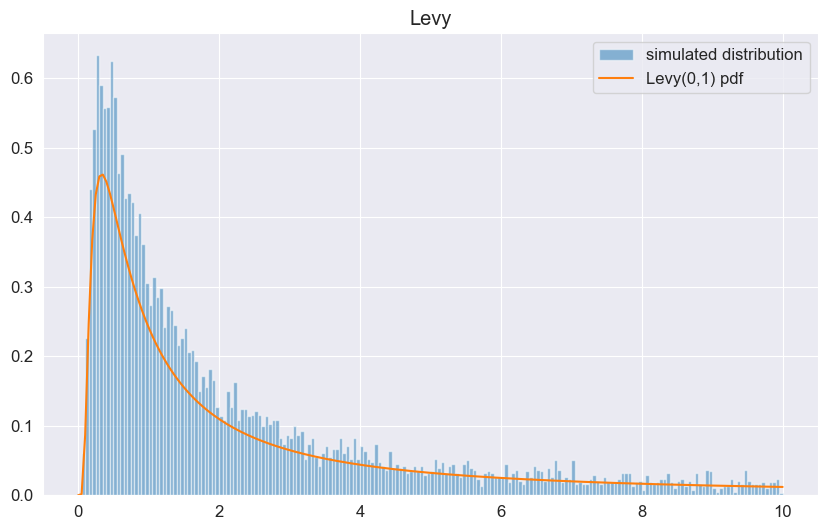

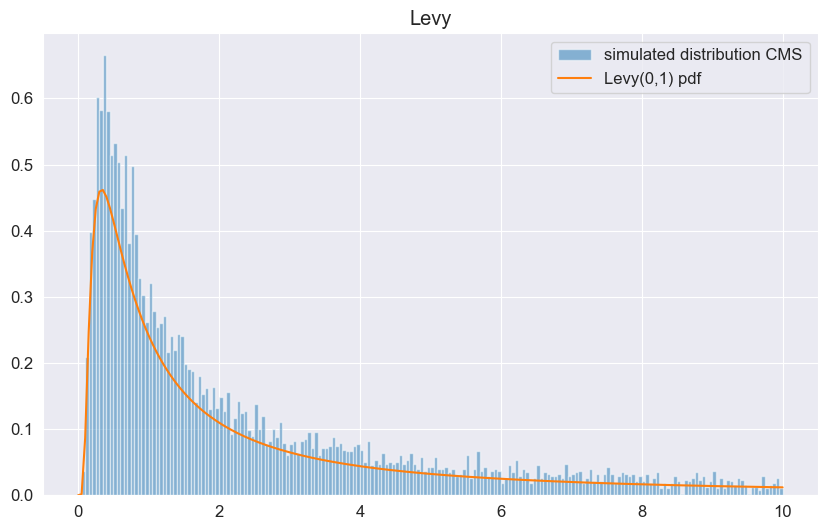

In [4]:
data = simulate_levy(n_steps=10000)
data_cms = simulate_stable(alpha=0.5, beta=1, n_steps=10000)

x = np.linspace(0,10,200)
plt.hist(data, bins=200, density=True, alpha=0.5, label = "simulated distribution", range=(0, 10))
plt.plot(x, stats.levy.pdf(x), label = r"Levy(0,1) pdf")
plt.title("Levy")
plt.legend()
plt.show()
plt.hist(data_cms, bins=200, density=True, alpha=0.5, label = "simulated distribution CMS", range=(0, 10))
plt.plot(x, stats.levy.pdf(x), label = r"Levy(0,1) pdf")
plt.title("Levy")
plt.legend()
plt.show()

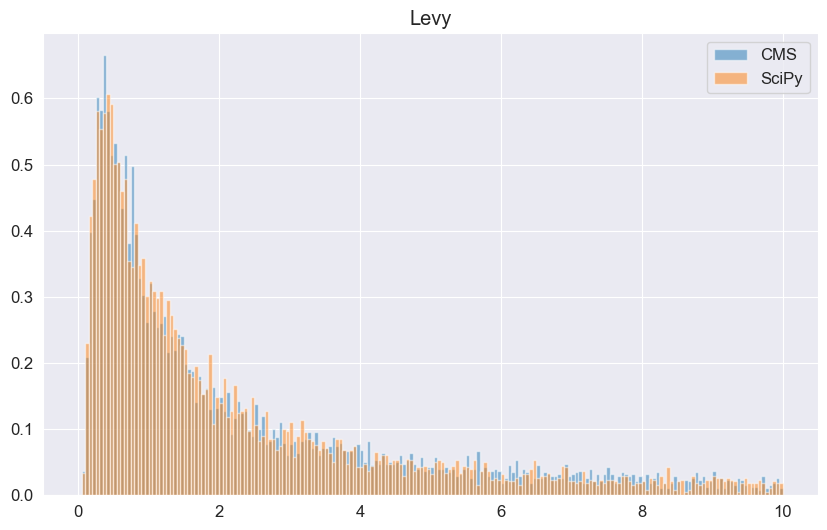

In [5]:
data_scipy = simulate_scipy(0.5, 1.0, size=10**4)

plt.hist(data_cms, bins=200, density=True, alpha=0.5, label="CMS", range=(0, 10))
plt.hist(data_scipy, bins=200, density=True, alpha=0.5, label="SciPy",range=(0, 10))

plt.legend()
plt.title("Levy")
plt.show()

## Tail exponent verification


We estimate $\alpha$ from the slope in log-log space.

In [6]:
def estimate_tail_alpha(data):
    data = np.abs(data)
    data = np.sort(data)

    tail = data[int(0.9 * len(data)):]
    ccdf = 1 - np.arange(len(tail)) / len(tail)

    x = np.log(tail)
    y = np.log(ccdf)

    slope, _ = np.polyfit(x, y, 1)
    return -slope


alpha_est = estimate_tail_alpha(data_cms)
print("Estimated alpha (tail):", alpha_est)

Estimated alpha (tail): 0.4502715671974686


In [7]:
cases = [
    (1.0, 0.0, "Cauchy"),
    (0.5, 1.0, "Levy"),
]

results = []

for alpha, beta, name in cases:
    data = simulate_stable(alpha= alpha, beta=beta, n_steps=100000)
    alpha_tail = estimate_tail_alpha(data)

    results.append((name, alpha, alpha_tail))

for r in results:
    print(f"{r[0]}: true {r[1]}, tail {r[2]:.3f}")

Cauchy: true 1.0, tail 1.014
Levy: true 0.5, tail 0.512


## Simulating process

In [8]:
def simulate_levy_flight(n_steps=1000, alpha=0.5):
    steps = simulate_stable(alpha, beta = 1, n_steps=n_steps)

    angles = np.random.uniform(0, 2*np.pi, n_steps)

    dx = steps * np.cos(angles)
    dy = steps * np.sin(angles)

    x = np.cumsum(dx)
    y = np.cumsum(dy)

    return x, y, steps

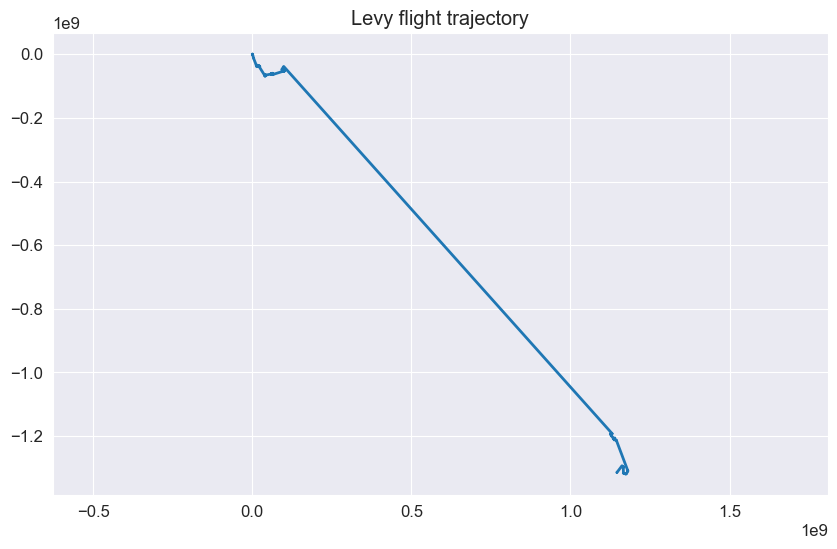

In [9]:
x, y, steps = simulate_levy_flight(50000, alpha=0.5)

plt.plot(x, y, linewidth=2, )
plt.title("Levy flight trajectory")
plt.axis("equal")
plt.show()

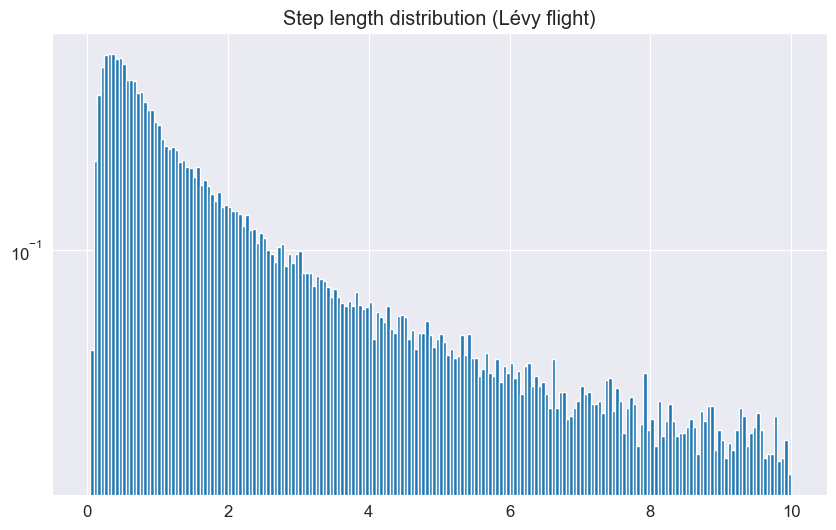

In [10]:
plt.hist(np.abs(steps), bins=200, density=True, range = (0,10))
plt.yscale("log")
plt.title("Step length distribution (Lévy flight)")
plt.show()

Estimators

In [16]:
import pandas as pd
from scipy.stats import levy_stable

scenarios = [
    ("Gaussian", 2.0, 0.0, 1.0, 0.0),
    ("Cauchy",   1.0, 0.0, 1.0, 5.0),
    ("Levy",     0.5, 1.0, 0.5, 0.0),
    ("Asymmetric", 1.5, 0.7, 1.2, -2.0),
    ("Heavy Tail", 0.8, -0.2, 1.0, 0.0)
]

results = []

for name, t_a, t_b, t_s, t_m in scenarios:
    print(f"Testing Scenario: {name}")
    # generate synthetic data
    data = simulate_scipy(alpha=t_a,beta=t_b, sigma=t_s,  mu=t_m, size=2500)
    mcc = mcculloch_estimator(data)
    kou = koutrouvelis_estimator(data)
    
    try:
        mle_raw = levy_stable.fit(data[:1000], method='mle')
        mle = (mle_raw[0], mle_raw[1], mle_raw[3], mle_raw[2])
    except:
        mle = (np.nan,)*4

    methods = {"McCulloch": mcc, "Koutrouvelis": kou, "SciPy_MLE": mle}
    
    for m_name, p in methods.items():
        results.append({
            "Scenario": name,
            "Method": m_name,
            "True_A": t_a, "Est_A": p[0], "Err_A": abs(p[0] - t_a),
            "True_B": t_b, "Est_B": p[1], "Err_B": abs(p[1] - t_b),
            "True_S": t_s, "Est_S": p[2], "Err_S": abs(p[2] - t_s),
            "True_M": t_m, "Est_M": p[3], "Err_M": abs(p[3] - t_m),
        })
    print(results)

df = pd.DataFrame(results)


display(df[["Scenario", "Method", "Est_A", "Est_B", "Est_S", "Est_M"]].round(3))

mae = df.groupby("Method")[["Err_A", "Err_B", "Err_S", "Err_M"]].mean()
display(mae.round(4))

Testing Scenario: Gaussian
[{'Scenario': 'Gaussian', 'Method': 'McCulloch', 'True_A': 2.0, 'Est_A': np.float64(1.8728338562360995), 'Err_A': np.float64(0.12716614376390045), 'True_B': 0.0, 'Est_B': np.float64(-0.07638850724533922), 'Err_B': np.float64(0.07638850724533922), 'True_S': 1.0, 'Est_S': np.float64(0.9426828696173415), 'Err_S': np.float64(0.05731713038265851), 'True_M': 0.0, 'Est_M': np.float64(-0.04249661081600591), 'Err_M': np.float64(0.04249661081600591)}, {'Scenario': 'Gaussian', 'Method': 'Koutrouvelis', 'True_A': 2.0, 'Est_A': np.float64(2.0007417081134284), 'Err_A': np.float64(0.0007417081134284409), 'True_B': 0.0, 'Est_B': np.float64(0.013324412882853453), 'Err_B': np.float64(0.013324412882853453), 'True_S': 1.0, 'Est_S': np.float64(1.0094651700591097), 'Err_S': np.float64(0.00946517005910974), 'True_M': 0.0, 'Est_M': np.float64(-0.008649905160612367), 'Err_M': np.float64(0.008649905160612367)}, {'Scenario': 'Gaussian', 'Method': 'SciPy_MLE', 'True_A': 2.0, 'Est_A': np

,Scenario,Method,Est_A,Est_B,Est_S,Est_M
0,Gaussian,McCulloch,1.873,-0.076,0.943,-0.042
1,Gaussian,Koutrouvelis,2.001,0.013,1.009,-0.009
2,Gaussian,SciPy_MLE,2.000,-1.000,1.027,-0.024
3,Cauchy,McCulloch,1.026,-0.070,1.051,4.947
4,Cauchy,Koutrouvelis,1.044,-0.039,1.056,4.928
5,Cauchy,SciPy_MLE,1.054,-0.027,1.114,4.563
6,Levy,McCulloch,0.501,1.000,2.327,1.092
7,Levy,Koutrouvelis,0.503,-0.700,0.514,0.659
8,Levy,SciPy_MLE,0.482,1.000,0.521,0.008
9,Asymmetric,McCulloch,1.488,0.748,1.232,-2.571


,Err_A,Err_B,Err_S,Err_M
Method,,,,
Koutrouvelis,0.0207,0.6074,0.0274,0.4448
McCulloch,0.0381,0.0418,0.4075,0.4931
SciPy_MLE,0.0182,0.2393,0.0525,0.1591


In [17]:
df.round(3)

,Scenario,Method,True_A,Est_A,Err_A,True_B,Est_B,Err_B,True_S,Est_S,Err_S,True_M,Est_M,Err_M
0,Gaussian,McCulloch,2.0,1.873,0.127,0.0,-0.076,0.076,1.0,0.943,0.057,0.0,-0.042,0.042
1,Gaussian,Koutrouvelis,2.0,2.001,0.001,0.0,0.013,0.013,1.0,1.009,0.009,0.0,-0.009,0.009
2,Gaussian,SciPy_MLE,2.0,2.000,0.000,0.0,-1.000,1.000,1.0,1.027,0.027,0.0,-0.024,0.024
3,Cauchy,McCulloch,1.0,1.026,0.026,0.0,-0.070,0.070,1.0,1.051,0.051,5.0,4.947,0.053
4,Cauchy,Koutrouvelis,1.0,1.044,0.044,0.0,-0.039,0.039,1.0,1.056,0.056,5.0,4.928,0.072
5,Cauchy,SciPy_MLE,1.0,1.054,0.054,0.0,-0.027,0.027,1.0,1.114,0.114,5.0,4.563,0.437
6,Levy,McCulloch,0.5,0.501,0.001,1.0,1.000,0.000,0.5,2.327,1.827,0.0,1.092,1.092
7,Levy,Koutrouvelis,0.5,0.503,0.003,1.0,-0.700,1.700,0.5,0.514,0.014,0.0,0.659,0.659
8,Levy,SciPy_MLE,0.5,0.482,0.018,1.0,1.000,0.000,0.5,0.521,0.021,0.0,0.008,0.008
9,Asymmetric,McCulloch,1.5,1.488,0.012,0.7,0.748,0.048,1.2,1.232,0.032,-2.0,-2.571,0.571


In [18]:
mae.round(4)

,Err_A,Err_B,Err_S,Err_M
Method,,,,
Koutrouvelis,0.0207,0.6074,0.0274,0.4448
McCulloch,0.0381,0.0418,0.4075,0.4931
SciPy_MLE,0.0182,0.2393,0.0525,0.1591
